# Diabetes Prediction

---







In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# loading the diabetes dataset to a pandas DataFrame
diabetes_dataset = pd.read_csv('/content/diabetes.csv')

In [ ]:
# printing the first 5 rows of the dataset
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# number of rows and Columns in this dataset
diabetes_dataset.shape

(768, 9)

In [ ]:
diabetes_dataset.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# getting the statistical measures of the data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


## Logistic Regression model


---



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Separating features and target
X = diabetes_dataset.drop(columns='Outcome', axis=1)
Y = diabetes_dataset['Outcome']

# Standardizing the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Splitting the dataset
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

# Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, Y_train)

# Model Evaluation
train_predictions = model.predict(X_train)
train_accuracy = accuracy_score(Y_train, train_predictions)

test_predictions = model.predict(X_test)
test_accuracy = accuracy_score(Y_test, test_predictions)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

# Predict for a single instance
input_data = (5,166,72,19,175,25.8,0.587,51)
input_data_as_numpy_array = np.asarray(input_data).reshape(1, -1)

# Standardize the input data
std_data = scaler.transform(input_data_as_numpy_array)

# Make a prediction
prediction = model.predict(std_data)

if prediction[0] == 0:
    print('The person is not diabetic')
else:
    print('The person is diabetic')


Training Accuracy: 0.7850162866449512
Test Accuracy: 0.7597402597402597
The person is diabetic


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## SVM model

---



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

# Load the dataset
diabetes_dataset = pd.read_csv('/content/diabetes.csv')

# Separating features and target
X = diabetes_dataset.drop(columns='Outcome', axis=1)
Y = diabetes_dataset['Outcome']

# Standardizing the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Splitting the dataset
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

# Initialize and train the SVM model
classifier = svm.SVC(kernel='linear')
classifier.fit(X_train, Y_train)

# Model Evaluation
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

print("Training Accuracy:", training_data_accuracy)
print("Test Accuracy:", test_data_accuracy)

# Predict for a single instance
input_data = (4,110,92,0,0,37.6,0.191,30)
#input_data = (8,180,80,20,200,35.5,0.8,55)
input_data_as_numpy_array = np.asarray(input_data).reshape(1, -1)

# Standardize the input data
std_data = scaler.transform(input_data_as_numpy_array)

# Make a prediction
prediction = classifier.predict(std_data)

if prediction[0] == 0:
    print('The person is not diabetic')
else:
    print('The person is diabetic')


Training Accuracy: 0.7866449511400652
Test Accuracy: 0.7727272727272727
The person is not diabetic


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## XGBoost model

---



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Separating features and target
X = diabetes_dataset.drop(columns='Outcome', axis=1)
Y = diabetes_dataset['Outcome']

# Standardizing the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Splitting the dataset
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

# Initialize and train the XGBoost model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, Y_train)

# Model Evaluation
train_predictions = model.predict(X_train)
train_accuracy = accuracy_score(Y_train, train_predictions)

test_predictions = model.predict(X_test)
test_accuracy = accuracy_score(Y_test, test_predictions)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

# Predict for a single instance
input_data = (5,166,72,19,175,25.8,0.587,51)
input_data_as_numpy_array = np.asarray(input_data).reshape(1, -1)

# Standardize the input data
std_data = scaler.transform(input_data_as_numpy_array)

# Make a prediction
prediction = model.predict(std_data)

if prediction[0] == 0:
    print('The person is not diabetic')
else:
    print('The person is diabetic')


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:03:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Accuracy: 1.0
Test Accuracy: 0.7402597402597403
The person is diabetic


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Random Forest model




---




In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Separating features and target
X = diabetes_dataset.drop(columns='Outcome', axis=1)
Y = diabetes_dataset['Outcome']

# Standardizing the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Splitting the dataset
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=2)
rf_model.fit(X_train, Y_train)

# Model Evaluation
train_predictions = rf_model.predict(X_train)
train_accuracy = accuracy_score(Y_train, train_predictions)

test_predictions = rf_model.predict(X_test)
test_accuracy = accuracy_score(Y_test, test_predictions)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

# Predict for a single instance
input_data = (2,100,60,5,90,22.5,0.2,30)
input_data_as_numpy_array = np.asarray(input_data).reshape(1, -1)

# Standardize the input data
std_data = scaler.transform(input_data_as_numpy_array)

# Make a prediction
prediction = rf_model.predict(std_data)

if prediction[0] == 0:
    print('The person is not diabetic')
else:
    print('The person is diabetic')


Training Accuracy: 0.8599348534201955
Test Accuracy: 0.7532467532467533
The person is not diabetic


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


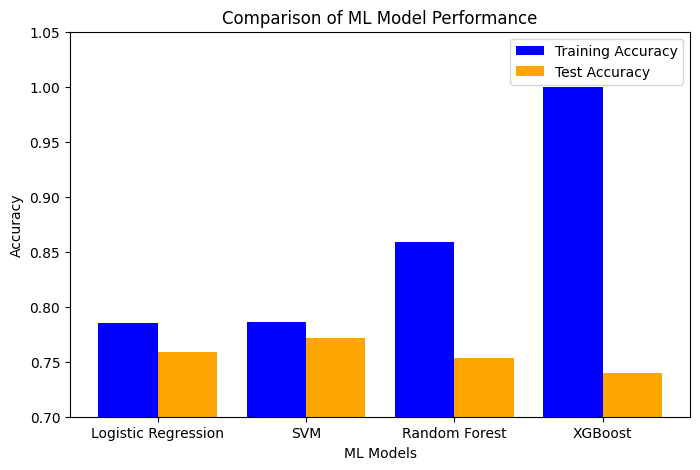

In [ ]:
models = ["Logistic Regression", "SVM", "Random Forest", "XGBoost"]

train_accuracies = [0.785, 0.786, 0.859, 1.00]
test_accuracies = [0.759, 0.772, 0.753, 0.740]
x = np.arange(len(models))

plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, train_accuracies, width=0.4, label="Training Accuracy", color='blue')
plt.bar(x + 0.2, test_accuracies, width=0.4, label="Test Accuracy", color='orange')
plt.xlabel("ML Models")
plt.ylabel("Accuracy")
plt.title("Comparison of ML Model Performance")
plt.xticks(ticks=x, labels=models)
plt.ylim(0.7, 1.05)
plt.legend()
plt.show()
